# Разведочный анализ данных: Zillow (logerror)

EDA для соревнования Zillow: анализ `train_2016_v2.csv` и подвыборки `properties_2016.csv`, распределение `logerror`, динамика по времени и корреляции признаков недвижимости.


In [ ]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("seaborn-v0_8")
sns.set_theme()

DATA_DIR = os.path.join("..", "datasets")
TRAIN_2016_PATH = os.path.join(DATA_DIR, "train_2016_v2.csv")
TRAIN_2017_PATH = os.path.join(DATA_DIR, "train_2017.csv")
PROPS_2016_PATH = os.path.join(DATA_DIR, "properties_2016.csv")
PROPS_2017_PATH = os.path.join(DATA_DIR, "properties_2017.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

train2016 = pd.read_csv(TRAIN_2016_PATH)
print("train_2016_v2:", train2016.shape)
display(train2016.head())

print("\nИнформация train_2016_v2:")
train2016.info()

print("\nПропуски train_2016_v2:")
display(train2016.isna().sum().sort_values(ascending=False).head(10))

target_col = "logerror"


train_2016_v2: (90275, 3)


,parcelid,logerror,transactiondate
0,11016594,0.0276,2016-01-01
1,14366692,-0.1684,2016-01-01
2,12098116,-0.0040,2016-01-01
3,12643413,0.0218,2016-01-02
4,14432541,-0.0050,2016-01-02



Информация train_2016_v2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90275 entries, 0 to 90274
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   parcelid         90275 non-null  int64  
 1   logerror         90275 non-null  float64
 2   transactiondate  90275 non-null  object 
dtypes: float64(1), int64(1), object(1)
memory usage: 2.1+ MB

Пропуски train_2016_v2:


parcelid           0
logerror           0
transactiondate    0
dtype: int64

## Целевая переменная (logerror)
Распределение logerror в обучающей выборке.

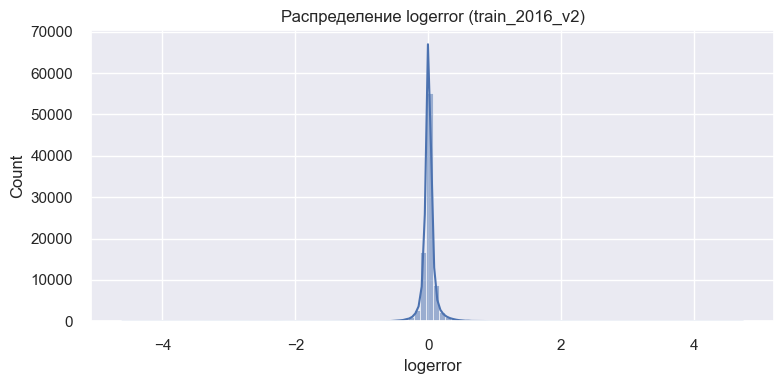

In [ ]:
if target_col in train2016.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(train2016[target_col], bins=100, kde=True)
    plt.title("Распределение logerror (train_2016_v2)")
    plt.tight_layout()
    plt.show()

## Динамика logerror по месяцам
Средний logerror по месяцам транзакций.

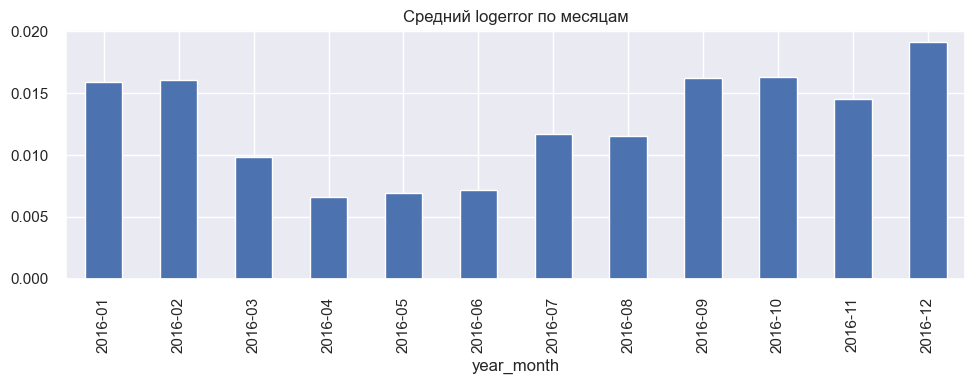

In [ ]:
train2016["transactiondate"] = pd.to_datetime(train2016["transactiondate"])
train2016["year_month"] = train2016["transactiondate"].dt.to_period("M")
plt.figure(figsize=(10, 4))
train2016.groupby("year_month")[target_col].mean().plot(kind="bar")
plt.title("Средний logerror по месяцам")
plt.tight_layout()
plt.show()

## Таблица properties_2016
Загрузка подвыборки и анализ пропусков.

In [ ]:
print("Чтение подвыборки properties_2016 для EDA (чтобы не перегружать память)...")
props2016 = pd.read_csv(PROPS_2016_PATH, nrows=200000)
print("properties_2016 (sample):", props2016.shape)
display(props2016.head())

missing_props = props2016.isna().sum().sort_values(ascending=False)
print("\nПропуски (properties_2016, sample):")
display(missing_props.head(20))

numeric_cols = props2016.select_dtypes(include=[np.number]).columns.tolist()
sample_props = props2016.sample(n=min(len(props2016), 20000), random_state=42)

Чтение подвыборки properties_2016 для EDA (чтобы не перегружать память)...


C:\Users\tetif\AppData\Local\Temp\ipykernel_12840\849576505.py:2: DtypeWarning: Columns (49) have mixed types. Specify dtype option on import or set low_memory=False.
  props2016 = pd.read_csv(PROPS_2016_PATH, nrows=200000)


properties_2016 (sample): (200000, 58)


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,finishedfloor1squarefeet,calculatedfinishedsquarefeet,finishedsquarefeet12,finishedsquarefeet13,finishedsquarefeet15,finishedsquarefeet50,finishedsquarefeet6,fips,fireplacecnt,fullbathcnt,garagecarcnt,garagetotalsqft,hashottuborspa,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,poolcnt,poolsizesum,pooltypeid10,pooltypeid2,pooltypeid7,propertycountylandusecode,propertylandusetypeid,propertyzoningdesc,rawcensustractandblock,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,storytypeid,threequarterbathnbr,typeconstructiontypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock
0,10754147,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6037,NaN,NaN,NaN,NaN,NaN,NaN,34144442,-118654084,85768.0,NaN,NaN,NaN,NaN,NaN,010D,269,NaN,6.037800e+07,37688.0,3101,NaN,96337.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,2015,9.0,NaN,NaN,NaN,NaN
1,10759547,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6037,NaN,NaN,NaN,NaN,NaN,NaN,34140430,-118625364,4083.0,NaN,NaN,NaN,NaN,NaN,0109,261,LCA11*,6.037800e+07,37688.0,3101,NaN,96337.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27516.0,2015,27516.0,NaN,NaN,NaN,NaN
2,10843547,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,73026.0,NaN,NaN,73026.0,NaN,NaN,6037,NaN,NaN,NaN,NaN,NaN,NaN,33989359,-118394633,63085.0,NaN,NaN,NaN,NaN,NaN,1200,47,LAC2,6.037703e+07,51617.0,3101,NaN,96095.0,0.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,650756.0,1413387.0,2015,762631.0,20800.37,NaN,NaN,NaN
3,10859147,NaN,NaN,NaN,0.0,0.0,3.0,7.0,NaN,NaN,NaN,5068.0,NaN,NaN,5068.0,NaN,NaN,6037,NaN,NaN,NaN,NaN,NaN,NaN,34148863,-118437206,7521.0,NaN,NaN,NaN,NaN,NaN,1200,47,LAC2,6.037141e+07,12447.0,3101,27080.0,96424.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1948.0,1.0,NaN,571346.0,1156834.0,2015,585488.0,14557.57,NaN,NaN,NaN
4,10879947,NaN,NaN,NaN,0.0,0.0,4.0,NaN,NaN,NaN,NaN,1776.0,NaN,NaN,1776.0,NaN,NaN,6037,NaN,NaN,NaN,NaN,NaN,NaN,34194168,-118385816,8512.0,NaN,NaN,NaN,NaN,NaN,1210,31,LAM1,6.037123e+07,12447.0,3101,46795.0,96450.0,0.0,NaN,NaN,NaN,1.0,NaN,NaN,1947.0,NaN,NaN,193796.0,433491.0,2015,239695.0,5725.17,NaN,NaN,NaN



Пропуски (properties_2016, sample):


storytypeid                 199900
basementsqft                199900
yardbuildingsqft26          199804
fireplaceflag               199684
architecturalstyletypeid    199634
typeconstructiontypeid      199585
finishedsquarefeet13        199459
buildingclasstypeid         199118
decktypeid                  198833
finishedsquarefeet6         198589
poolsizesum                 198100
pooltypeid2                 197899
pooltypeid10                197594
taxdelinquencyyear          196139
taxdelinquencyflag          196139
hashottuborspa              195493
yardbuildingsqft17          194374
finishedsquarefeet15        187148
finishedsquarefeet50        185912
finishedfloor1squarefeet    185912
dtype: int64

## Корреляционная матрица (properties_2016)
Корреляции Пирсона по блокам признаков (числа в ячейках — коэффициенты). Признаков много, поэтому матрица разбита на блоки по 12 столбцов.

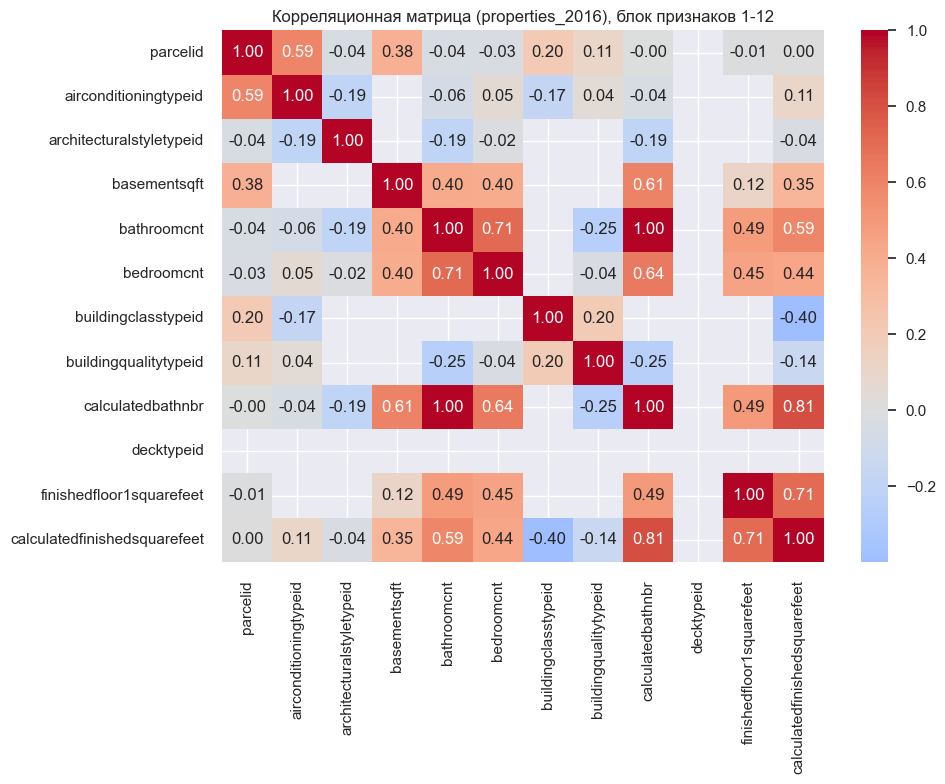

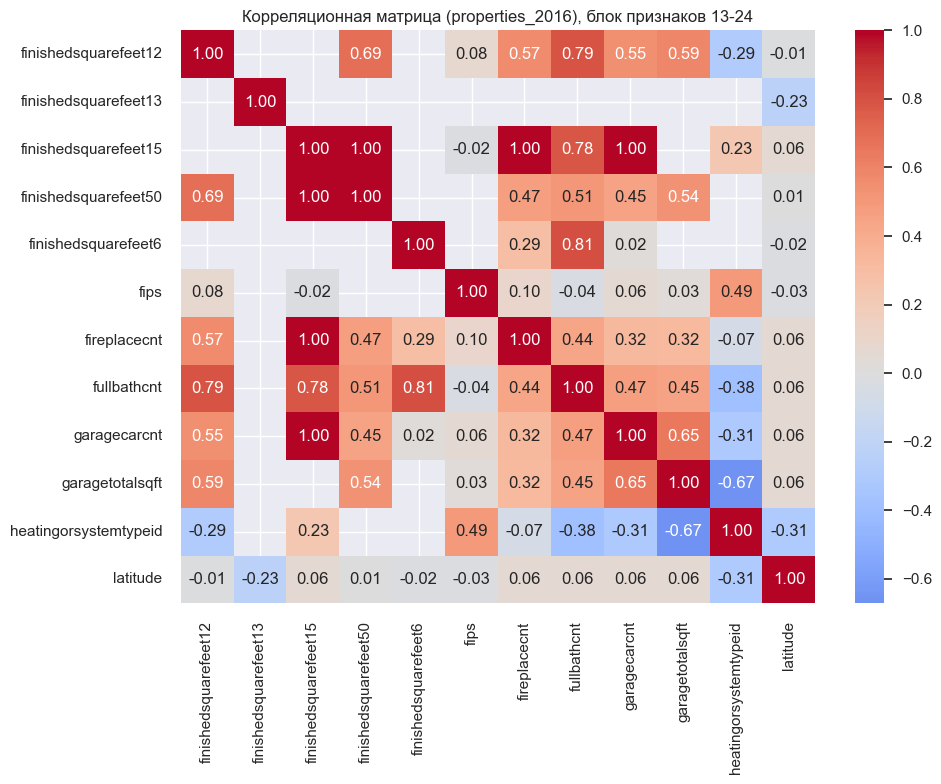

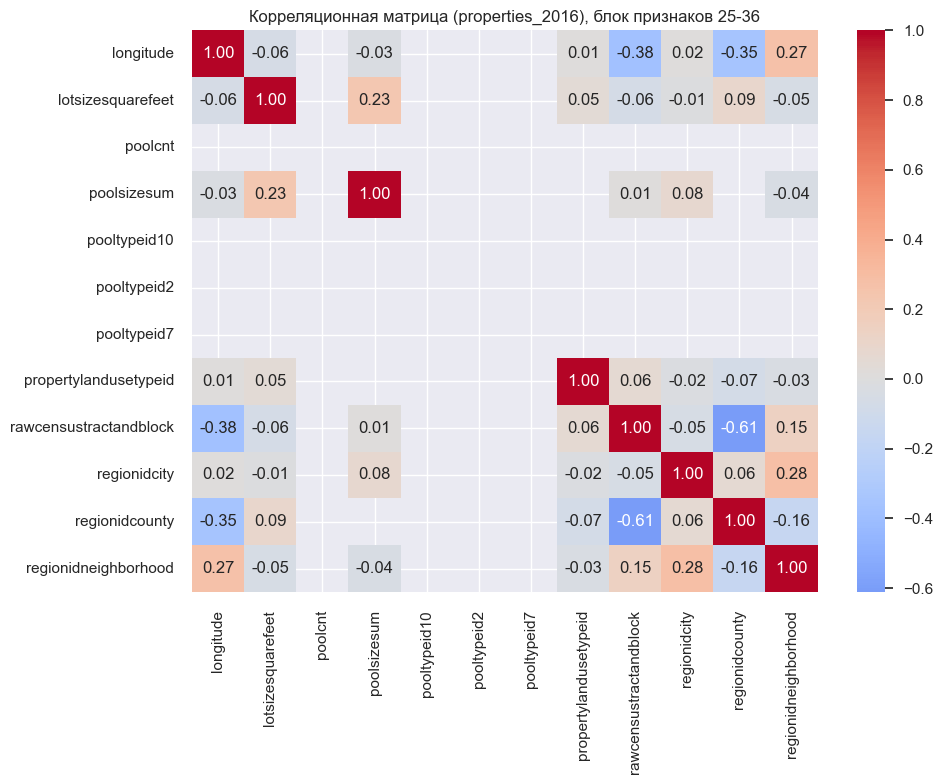

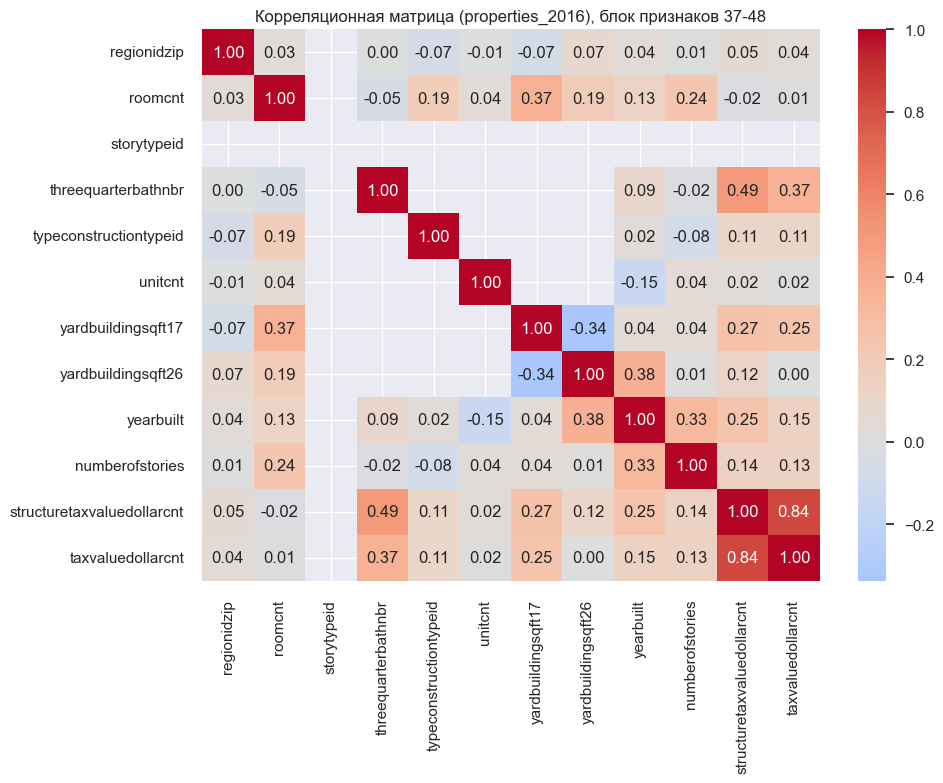

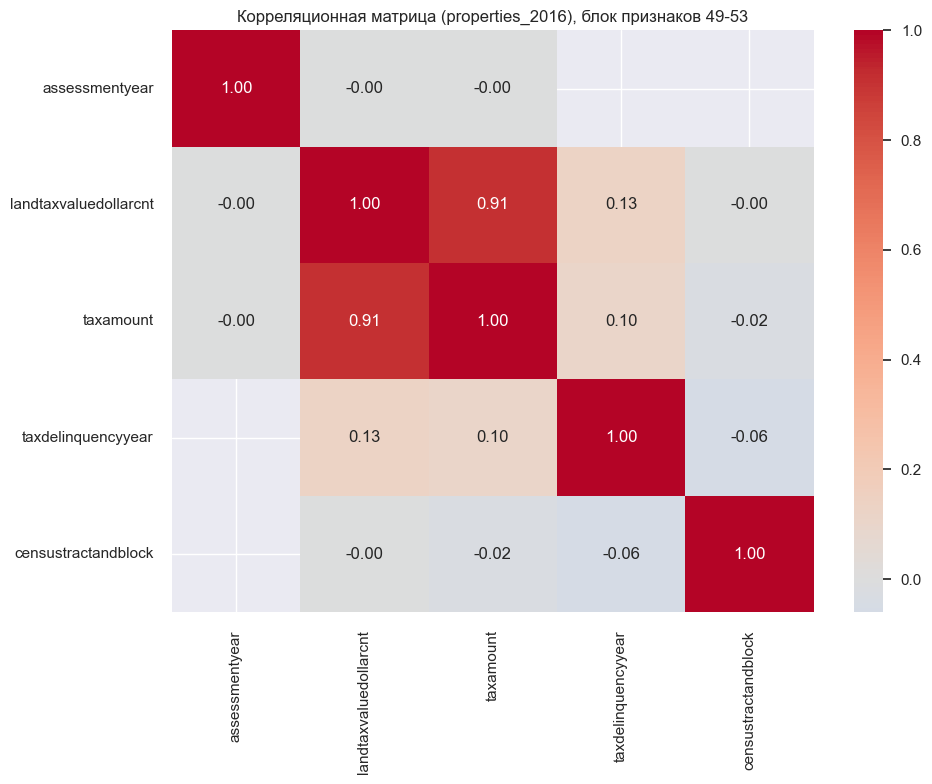

In [ ]:
if numeric_cols:
    block_size = 12
    for start in range(0, len(numeric_cols), block_size):
        cols_block = numeric_cols[start : start + block_size]
        corr = sample_props[cols_block].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
        plt.title(f"Корреляционная матрица (properties_2016), блок признаков {start + 1}-{start + len(cols_block)}")
        plt.tight_layout()
        plt.show()